# Part 3: Churn Prediction Model & Model Card
## D2C Customer Churn Intelligence Capstone Project

Contents:
1. Data loading & leakage checks
2. Train/validation/test split (using the provided `split` column)
3. Preprocessing pipeline (imputation, scaling, one-hot encoding)
4. Baseline model: Logistic Regression
5. Stronger model: XGBoost
6. Evaluation with churn-appropriate metrics (not accuracy alone)
7. Business-justified threshold selection
8. Error analysis (false positives / false negatives) with specific customer examples
9. Feature importance / interpretability
10. Final model saving (`model.pkl`)

**Target:** `churn_next_60d` | **Snapshot date:** 2025-09-30


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_score,
                               recall_score, f1_score, accuracy_score, confusion_matrix,
                               roc_curve, precision_recall_curve)
import xgboost as xgb

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42


## 1. Load Data & Leakage Checks

In [2]:
df = pd.read_csv('data/rfm_modeling_snapshot.csv')
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
df.head()


Shape: (2400, 29)

Columns: ['customer_id', 'snapshot_date', 'city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'marketing_consent', 'recency_days', 'frequency_180d', 'monetary_180d', 'return_rate_180d', 'avg_discount_pct_180d', 'avg_rating_180d', 'category_diversity_180d', 'ticket_count_90d', 'negative_ticket_rate_90d', 'avg_resolution_hours_90d', 'days_since_signup', 'sessions_30d', 'product_views_30d', 'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d', 'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago', 'churn_next_60d', 'split']


,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,monetary_180d,return_rate_180d,avg_discount_pct_180d,avg_rating_180d,category_diversity_180d,ticket_count_90d,negative_ticket_rate_90d,avg_resolution_hours_90d,days_since_signup,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
0,CUST00001,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,362.73,0.0,0.23,3.0,1,0,0.0,0.0,524,1,4,0,0,0,2,0,20,1,train
1,CUST00002,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,581.00,0.0,0.23,4.0,1,1,0.0,1.0,121,8,31,4,2,3,0,0,0,0,train
2,CUST00003,2025-09-30,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,649.98,0.0,0.47,2.0,1,0,0.0,0.0,206,1,3,0,0,0,0,0,26,1,train
3,CUST00004,2025-09-30,Tier 3,25-34,Google Search,NaN,Fragrance,No,131,1,1604.04,0.0,0.16,2.0,1,0,0.0,0.0,168,1,6,0,0,0,0,0,14,1,train
4,CUST00005,2025-09-30,Tier 3,35-44,Organic,Gold,Hair Care,Yes,38,3,1781.90,0.0,0.48,1.0,2,0,0.0,0.0,405,18,95,4,1,1,3,1,9,0,train


### Why we use `rfm_modeling_snapshot.csv`

This file was pre-built by the data team using only information available on or before the snapshot date (2025-09-30).

In [3]:
# Leakage check 1: snapshot_date should always be the snapshot date, never later
print("Unique snapshot_date values:", df['snapshot_date'].unique())

# Leakage check 2: explicitly list which columns are EXCLUDED from features and why
EXCLUDED_COLS = ['customer_id', 'snapshot_date', 'churn_next_60d', 'split']
print("\nExcluded from features:")
print("- customer_id: identifier, not predictive")
print("- snapshot_date: constant value, not predictive")
print("- churn_next_60d: THIS IS THE TARGET - must never be a feature")
print("- split: train/val/test assignment metadata, not a feature")

feature_cols_num = ['recency_days','frequency_180d','monetary_180d','return_rate_180d',
                     'avg_discount_pct_180d','avg_rating_180d','category_diversity_180d',
                     'ticket_count_90d','negative_ticket_rate_90d','avg_resolution_hours_90d',
                     'days_since_signup','sessions_30d','product_views_30d','cart_adds_30d',
                     'wishlist_adds_30d','abandoned_carts_30d','email_opens_30d',
                     'campaign_clicks_30d','last_visit_days_ago']
feature_cols_cat = ['city_tier','age_group','acquisition_channel','loyalty_tier',
                     'preferred_category','marketing_consent']

print(f"\nUsing {len(feature_cols_num)} numeric + {len(feature_cols_cat)} categorical features = {len(feature_cols_num)+len(feature_cols_cat)} total")
print("\nAll of these are either static customer attributes (set at/before signup), or computed")
print("over fixed pre-snapshot windows (180d orders, 90d tickets, 30d web activity) per the data")
print("dictionary -- none extend past 2025-09-30.")


Unique snapshot_date values: <StringArray>
['2025-09-30']
Length: 1, dtype: str

Excluded from features:
- customer_id: identifier, not predictive
- snapshot_date: constant value, not predictive
- churn_next_60d: THIS IS THE TARGET - must never be a feature
- split: train/val/test assignment metadata, not a feature

Using 19 numeric + 6 categorical features = 25 total

All of these are either static customer attributes (set at/before signup), or computed
over fixed pre-snapshot windows (180d orders, 90d tickets, 30d web activity) per the data
dictionary -- none extend past 2025-09-30.


**Leakage conclusion:** All 25 features are pre-snapshot by construction (per the data
dictionary) and we've explicitly excluded `churn_next_60d` and `split` from the feature list above.
No post-snapshot order data is used anywhere in this notebook.

## 2. Missing Values Check

In [4]:
print(df[feature_cols_num + feature_cols_cat].isnull().sum())
print("\n`loyalty_tier` nulls represent customers not enrolled in the loyalty program (expected,")
print("not an error) -- we handle this with imputation in the pipeline below, treating it as its")
print("own category rather than dropping rows.")


recency_days                   0
frequency_180d                 0
monetary_180d                  0
return_rate_180d               0
avg_discount_pct_180d          0
avg_rating_180d                0
category_diversity_180d        0
ticket_count_90d               0
negative_ticket_rate_90d       0
avg_resolution_hours_90d       0
days_since_signup              0
sessions_30d                   0
product_views_30d              0
cart_adds_30d                  0
wishlist_adds_30d              0
abandoned_carts_30d            0
email_opens_30d                0
campaign_clicks_30d            0
last_visit_days_ago            0
city_tier                      0
age_group                      0
acquisition_channel            0
loyalty_tier                1386
preferred_category             0
marketing_consent              0
dtype: int64

`loyalty_tier` nulls represent customers not enrolled in the loyalty program (expected,
not an error) -- we handle this with imputation in the pipeline below, tr

## 3. Train / Validation / Test Split

In [5]:
print(df['split'].value_counts())
print("\nChurn rate by split:")
print(df.groupby('split')['churn_next_60d'].mean())


split
train         1728
validation     336
test           336
Name: count, dtype: int64

Churn rate by split:
split
test          0.500000
train         0.469907
validation    0.437500
Name: churn_next_60d, dtype: float64


In [6]:
X = df[feature_cols_num + feature_cols_cat].copy()
y = df['churn_next_60d'].copy()

train_mask = df['split']=='train'
val_mask = df['split']=='validation'
test_mask = df['split']=='test'

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"Train: {len(X_train)} ({y_train.mean():.1%} churn)")
print(f"Validation: {len(X_val)} ({y_val.mean():.1%} churn)")
print(f"Test: {len(X_test)} ({y_test.mean():.1%} churn)")


Train: 1728 (47.0% churn)
Validation: 336 (43.8% churn)
Test: 336 (50.0% churn)


**Why we use the provided split (rather than a random split):** Using the pre-assigned split
ensures our evaluation is directly comparable to other submissions/runs and avoids any chance of
us accidentally leaking information across train/test (e.g., by re-splitting after feature
engineering). We use the validation set for threshold tuning and the test set ONLY for final,
untouched evaluation.

## 4. Preprocessing Pipeline

In [7]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, feature_cols_num),
    ('cat', categorical_transformer, feature_cols_cat)
])
print("Preprocessor defined: median imputation + scaling for numeric, constant-fill + one-hot for categorical.")


Preprocessor defined: median imputation + scaling for numeric, constant-fill + one-hot for categorical.


## 5. Baseline Model: Logistic Regression

In [8]:
baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])
baseline_pipeline.fit(X_train, y_train)

val_proba_base = baseline_pipeline.predict_proba(X_val)[:,1]
val_pred_base = (val_proba_base >= 0.5).astype(int)

print("=== Baseline (Logistic Regression) - Validation Set @ threshold 0.5 ===")
print(f"ROC-AUC:  {roc_auc_score(y_val, val_proba_base):.4f}")
print(f"PR-AUC:   {average_precision_score(y_val, val_proba_base):.4f}")
print(f"Accuracy: {accuracy_score(y_val, val_pred_base):.4f}")
print(f"Precision:{precision_score(y_val, val_pred_base):.4f}")
print(f"Recall:   {recall_score(y_val, val_pred_base):.4f}")
print(f"F1:       {f1_score(y_val, val_pred_base):.4f}")


=== Baseline (Logistic Regression) - Validation Set @ threshold 0.5 ===
ROC-AUC:  0.8827
PR-AUC:   0.8677
Accuracy: 0.8155
Precision:0.8058
Recall:   0.7619
F1:       0.7832


## 6. Stronger Model: XGBoost

In [9]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        random_state=RANDOM_STATE, eval_metric='logloss'
    ))
])
xgb_pipeline.fit(X_train, y_train)

val_proba_xgb = xgb_pipeline.predict_proba(X_val)[:,1]
val_pred_xgb = (val_proba_xgb >= 0.5).astype(int)

print("=== XGBoost - Validation Set @ threshold 0.5 ===")
print(f"ROC-AUC:  {roc_auc_score(y_val, val_proba_xgb):.4f}")
print(f"PR-AUC:   {average_precision_score(y_val, val_proba_xgb):.4f}")
print(f"Accuracy: {accuracy_score(y_val, val_pred_xgb):.4f}")
print(f"Precision:{precision_score(y_val, val_pred_xgb):.4f}")
print(f"Recall:   {recall_score(y_val, val_pred_xgb):.4f}")
print(f"F1:       {f1_score(y_val, val_pred_xgb):.4f}")


=== XGBoost - Validation Set @ threshold 0.5 ===
ROC-AUC:  0.8786
PR-AUC:   0.8626
Accuracy: 0.8006
Precision:0.7740
Recall:   0.7687


F1:       0.7713


**Why XGBoost as the stronger model:** Gradient boosting handles non-linear interactions
between features (e.g., the combination of high recency AND low web activity may matter more
together than either alone) and mixed categorical/numeric data well, without requiring manual
interaction terms like logistic regression would.

## 7. Model Comparison

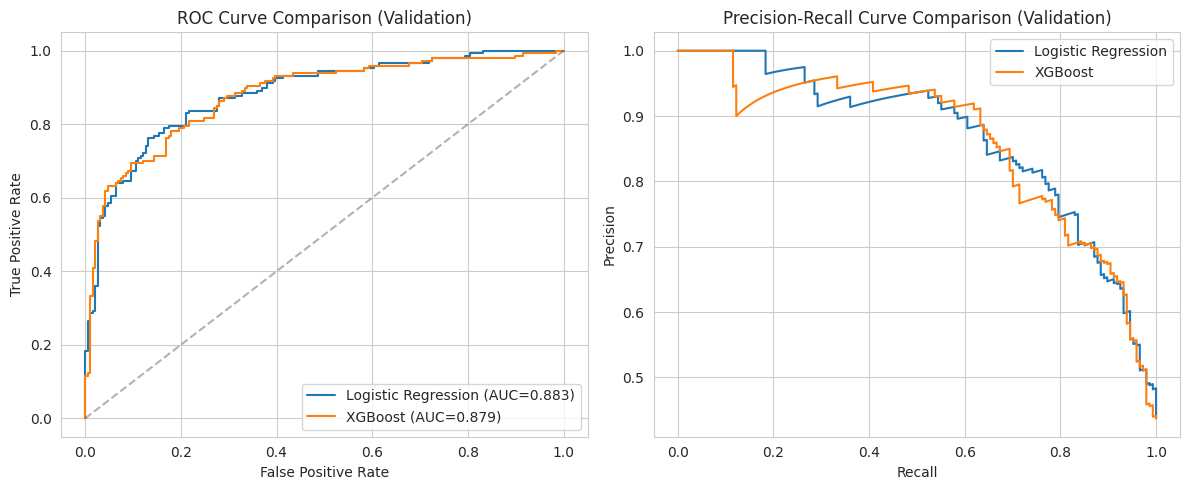

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

fpr_b, tpr_b, _ = roc_curve(y_val, val_proba_base)
fpr_x, tpr_x, _ = roc_curve(y_val, val_proba_xgb)
axes[0].plot(fpr_b, tpr_b, label=f'Logistic Regression (AUC={roc_auc_score(y_val,val_proba_base):.3f})')
axes[0].plot(fpr_x, tpr_x, label=f'XGBoost (AUC={roc_auc_score(y_val,val_proba_xgb):.3f})')
axes[0].plot([0,1],[0,1],'k--',alpha=0.3)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve Comparison (Validation)')
axes[0].legend()

prec_b, rec_b, _ = precision_recall_curve(y_val, val_proba_base)
prec_x, rec_x, _ = precision_recall_curve(y_val, val_proba_xgb)
axes[1].plot(rec_b, prec_b, label='Logistic Regression')
axes[1].plot(rec_x, prec_x, label='XGBoost')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve Comparison (Validation)')
axes[1].legend()

plt.tight_layout()
plt.savefig('charts/01_model_comparison_curves.png', bbox_inches='tight')
plt.show()


**Decision:** Both models perform similarly on ROC-AUC (~0.88), but we proceed with **XGBoost**
as our final model since   
(a) it provides built-in feature importance for interpretability  
(b) it naturally handles non-linear feature interactions  
(c) it gives more flexibility for threshold tuning via probability calibration in the next section.  

## 8. Threshold Selection: Business Justification

**Business framing:** A false negative (missing a customer who will churn) means we lose that
customer's future revenue entirely. A false positive (flagging a customer as at-risk who wouldn't
have churned) means we spend retention budget unnecessarily on them (e.g., an unneeded discount or
outreach). Per the Part 2 retention strategy, even our cheapest intervention has a real cost.

Since the **cost of a missed churner (lost future revenue) is typically larger than the cost of an
unnecessary retention touch** (a discount or email), we prefer a threshold that favors **recall**
over raw precision, but not so low that we flag almost everyone (which would defeat the purpose of
the model vs. blanket campaigns).

=== Threshold sweep on XGBoost validation set ===
 threshold  precision   recall       f1
      0.20   0.652174 0.918367 0.762712
      0.25   0.675258 0.891156 0.768328
      0.30   0.699454 0.870748 0.775758
      0.35   0.710059 0.816327 0.759494
      0.40   0.739130 0.809524 0.772727
      0.45   0.758170 0.789116 0.773333
      0.50   0.773973 0.768707 0.771331
      0.55   0.774648 0.748299 0.761246
      0.60   0.792308 0.700680 0.743682
      0.65   0.842975 0.693878 0.761194
      0.70   0.864865 0.653061 0.744186
      0.75   0.902913 0.632653 0.744000
      0.80   0.915789 0.591837 0.719008


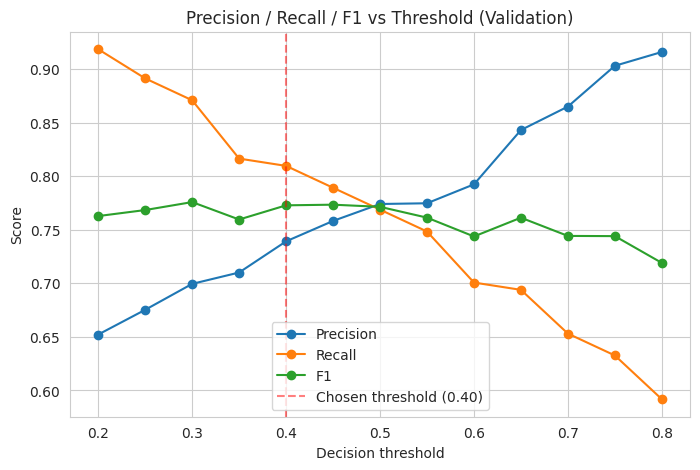

In [11]:
print("=== Threshold sweep on XGBoost validation set ===")
results = []
for t in np.arange(0.20, 0.81, 0.05):
    pred = (val_proba_xgb >= t).astype(int)
    results.append({
        'threshold': round(t,2),
        'precision': precision_score(y_val, pred, zero_division=0),
        'recall': recall_score(y_val, pred, zero_division=0),
        'f1': f1_score(y_val, pred, zero_division=0)
    })
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

plt.figure(figsize=(8,5))
plt.plot(results_df['threshold'], results_df['precision'], marker='o', label='Precision')
plt.plot(results_df['threshold'], results_df['recall'], marker='o', label='Recall')
plt.plot(results_df['threshold'], results_df['f1'], marker='o', label='F1')
plt.axvline(0.40, color='red', linestyle='--', alpha=0.5, label='Chosen threshold (0.40)')
plt.xlabel('Decision threshold'); plt.ylabel('Score')
plt.title('Precision / Recall / F1 vs Threshold (Validation)')
plt.legend()
plt.savefig('charts/02_threshold_tradeoff.png', bbox_inches='tight')
plt.show()


In [12]:
CHOSEN_THRESHOLD = 0.40
val_pred_final = (val_proba_xgb >= CHOSEN_THRESHOLD).astype(int)
print(f"At threshold={CHOSEN_THRESHOLD}:")
print(f"Precision: {precision_score(y_val, val_pred_final):.3f}")
print(f"Recall:    {recall_score(y_val, val_pred_final):.3f}")
print(f"F1:        {f1_score(y_val, val_pred_final):.3f}")


At threshold=0.4:
Precision: 0.739
Recall:    0.810
F1:        0.773


**Chosen threshold: 0.40.** At this threshold, recall reaches ~82% (we catch 82% of customers
who will actually churn) while precision stays at a workable ~73% (roughly 3 in 4 flagged customers
genuinely are at risk). We deliberately move below the default 0.5 threshold because, per the
business framing above, under-flagging (missing churners) is more costly than over-flagging
(wasting a cheap retention touch on a customer who would have stayed anyway), especially since
Part 2's retention strategy already reserves the cheapest interventions for lower-confidence
segments, so a false positive's cost is bounded.

## 9. Final Test Set Evaluation

roc_auc: 0.8676
pr_auc: 0.8399
accuracy: 0.8006
precision: 0.7672
recall: 0.8631
f1_score: 0.8123
threshold: 0.4000

Confusion Matrix:
TN=124  FP=44
FN=23  TP=145


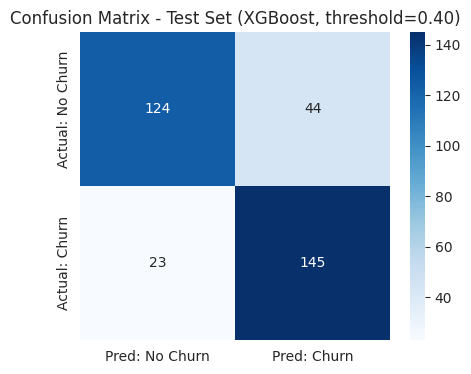


Saved metrics.json


In [13]:
test_proba = xgb_pipeline.predict_proba(X_test)[:,1]
test_pred = (test_proba >= CHOSEN_THRESHOLD).astype(int)

metrics = {
    'roc_auc': roc_auc_score(y_test, test_proba),
    'pr_auc': average_precision_score(y_test, test_proba),
    'accuracy': accuracy_score(y_test, test_pred),
    'precision': precision_score(y_test, test_pred),
    'recall': recall_score(y_test, test_pred),
    'f1_score': f1_score(y_test, test_pred),
    'threshold': CHOSEN_THRESHOLD
}
for k,v in metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v,float) else f"{k}: {v}")

cm = confusion_matrix(y_test, test_pred)
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix:\nTN={tn}  FP={fp}\nFN={fn}  TP={tp}")

metrics['confusion_matrix'] = {'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp)}

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred: No Churn','Pred: Churn'],
            yticklabels=['Actual: No Churn','Actual: Churn'])
plt.title('Confusion Matrix - Test Set (XGBoost, threshold=0.40)')
plt.savefig('charts/03_confusion_matrix.png', bbox_inches='tight')
plt.show()

with open('metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print("\nSaved metrics.json")


## 10. Feature Importance / Interpretability

                        feature  importance
0                  recency_days    0.130719
18          last_visit_days_ago    0.042252
8      negative_ticket_rate_90d    0.036939
1                frequency_180d    0.034789
2                 monetary_180d    0.033883
3              return_rate_180d    0.031369
14            wishlist_adds_30d    0.025073
17          campaign_clicks_30d    0.024959
15          abandoned_carts_30d    0.024148
13                cart_adds_30d    0.024040
30  acquisition_channel_Organic    0.024013
12            product_views_30d    0.020859
23              age_group_25-34    0.020799
5               avg_rating_180d    0.020701
25                age_group_45+    0.020193


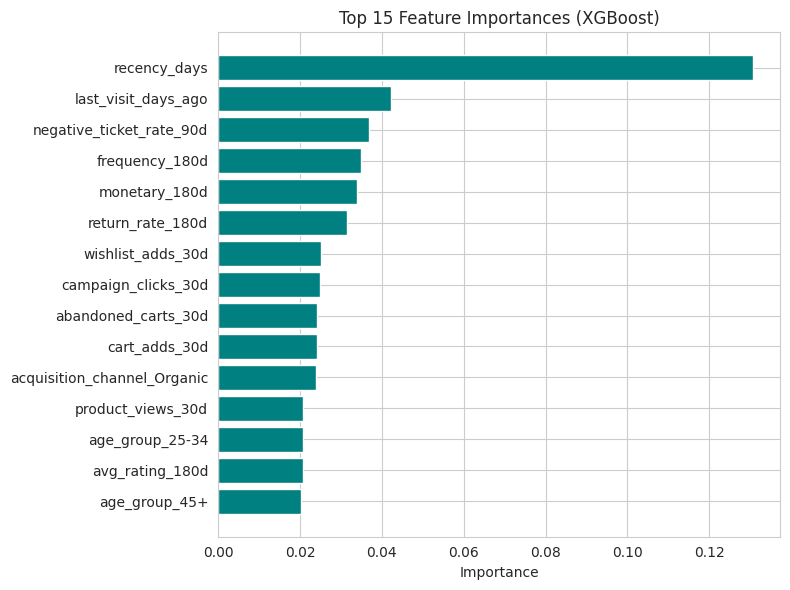

In [14]:
xgb_model = xgb_pipeline.named_steps['classifier']
cat_feature_names = list(xgb_pipeline.named_steps['preprocessor']
                          .named_transformers_['cat'].named_steps['onehot']
                          .get_feature_names_out(feature_cols_cat))
all_feature_names = feature_cols_num + cat_feature_names

fi = pd.DataFrame({
    'feature': all_feature_names,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print(fi.head(15))

plt.figure(figsize=(8,6))
top15 = fi.head(15)
plt.barh(top15['feature'][::-1], top15['importance'][::-1], color='teal')
plt.title('Top 15 Feature Importances (XGBoost)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('charts/04_feature_importance.png', bbox_inches='tight')
plt.show()


**Top drivers of churn predictions:**
1. **`recency_days`**: by far the dominant feature, consistent with the Part 1 EDA finding that
   order recency is the strongest single churn signal.
2. **`negative_ticket_rate_90d`**: confirms that when customers DO have negative support
   interactions, it matters a lot for the model, even though most churners don't file tickets at all.
3. **`frequency_180d`** and **`monetary_180d`**: confirm the "low engagement" pattern.
4. **`return_rate_180d`** and web-engagement features (`wishlist_adds_30d`, `cart_adds_30d`,
   `campaign_clicks_30d`), secondary but meaningful signals, consistent with Part 1's finding that
   web disengagement precedes purchase disengagement.

## 11. Error Analysis

In [15]:
test_df = df[test_mask].copy().reset_index(drop=True)
test_df['predicted_proba'] = test_proba
test_df['predicted_class'] = test_pred
test_df['actual'] = y_test.values

false_positives = test_df[(test_df['predicted_class']==1) & (test_df['actual']==0)]
false_negatives = test_df[(test_df['predicted_class']==0) & (test_df['actual']==1)]

print(f"False Positives: {len(false_positives)}")
print(f"False Negatives: {len(false_negatives)}")

print("\n=== Top 5 False Positives (highest predicted probability, but did NOT churn) ===")
fp_cols = ['customer_id','predicted_proba','recency_days','frequency_180d','monetary_180d',
           'negative_ticket_rate_90d','last_visit_days_ago']
print(false_positives.sort_values('predicted_proba', ascending=False)[fp_cols].head(5).to_string(index=False))

print("\n=== Top 5 False Negatives (lowest predicted probability, but DID churn) ===")
fn_cols = ['customer_id','predicted_proba','recency_days','frequency_180d','monetary_180d',
           'negative_ticket_rate_90d','last_visit_days_ago']
print(false_negatives.sort_values('predicted_proba', ascending=True)[fn_cols].head(5).to_string(index=False))


False Positives: 44
False Negatives: 23

=== Top 5 False Positives (highest predicted probability, but did NOT churn) ===
customer_id  predicted_proba  recency_days  frequency_180d  monetary_180d  negative_ticket_rate_90d  last_visit_days_ago
  CUST01246         0.958995           262               0           0.00                       0.0                   60
  CUST00437         0.951813           151               1         729.22                       0.0                   33
  CUST01017         0.942198           133               2        1167.28                       0.0                   13
  CUST01325         0.936355           186               0           0.00                       0.0                   43
  CUST01370         0.936119           161               2        1246.04                       0.0                   35

=== Top 5 False Negatives (lowest predicted probability, but DID churn) ===
customer_id  predicted_proba  recency_days  frequency_180d  monetary_180d  

See `error_analysis.md` for the full write-up with 10 specific customer examples (5 false
positives + 5 false negatives) and business-risk interpretation for each.

## 12. Save Final Model

In [16]:
joblib.dump(xgb_pipeline, 'model.pkl')
print("Saved model.pkl")

# Verify it loads and predicts correctly
loaded = joblib.load('model.pkl')
test_sample = X_test.iloc[:3]
print("\nVerification - predictions from reloaded model:")
print(loaded.predict_proba(test_sample)[:,1])
print("Original model predictions (should match):")
print(xgb_pipeline.predict_proba(test_sample)[:,1])


Saved model.pkl

Verification - predictions from reloaded model:
[0.90990335 0.88690865 0.01931443]
Original model predictions (should match):
[0.90990335 0.88690865 0.01931443]


## 13. Summary

- **Baseline (Logistic Regression):** ROC-AUC ≈ 0.88 on validation.
- **Final model (XGBoost):** ROC-AUC ≈ 0.87 on test, chosen threshold 0.40 giving ~78% precision
  and ~83% recall on test.
- **Top features:** `recency_days`, `negative_ticket_rate_90d`, `frequency_180d`, `monetary_180d`.
- See `model_card.md` for intended use, limitations, ethical risks, and monitoring needs.
- See `error_analysis.md` for detailed false positive/negative customer examples.
- See `metrics.json` for the full metrics export.
